In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna


In [3]:
def objective(trial, X_train, y_train, X_test, y_test):
    
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    return mse

In [4]:
def optimize_hyperparameters(X_train, y_train, X_test, y_test, n_trials=100):
    
    print(f"\nЗапуск оптимизации гиперпараметров ({n_trials} trials)...")
    
    study = optuna.create_study(direction='minimize')
    study.optimize(
        lambda trial: objective(trial, X_train, y_train, X_test, y_test), 
        n_trials=n_trials
    )
    
    print("\nЛучшие гиперпараметры:")
    for key, value in study.best_params.items():
        print(f"{key}: {value}")
    print(f"Лучшее MSE: {study.best_value:.4f}")
    
    return study.best_params

In [5]:
def train_final_model(X_train, y_train, best_params):
    
    model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    return model

In [6]:
def evaluate_model(model, X_test, y_test):
    """Оценка качества модели"""
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    print("\n" + "="*50)
    print("РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ")
    print("="*50)
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mae:.2f}%")
    
    return y_pred, {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

In [7]:
def plot_residuals(y_test, y_pred):
    
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # График 1: Predicted vs Actual
    axes[0].scatter(y_pred, y_test, alpha=0.6, color='blue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Actual Values')
    axes[0].set_title('Predicted vs Actual Values')
    axes[0].grid(True, alpha=0.3)
    
    # График 2: Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.6, color='green')
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals vs Predicted Values')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return residuals

[I 2025-10-08 11:57:36,526] A new study created in memory with name: no-name-804dac0f-3ec2-41e0-9c41-bf663bb60eb9



Запуск оптимизации гиперпараметров (50 trials)...


[I 2025-10-08 11:57:37,860] Trial 0 finished with value: 0.26287705063699246 and parameters: {'n_estimators': 159, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.26287705063699246.
[I 2025-10-08 11:57:40,214] Trial 1 finished with value: 0.46252765889393904 and parameters: {'n_estimators': 280, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.26287705063699246.
[I 2025-10-08 11:57:40,549] Trial 2 finished with value: 0.3042957723437807 and parameters: {'n_estimators': 55, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.26287705063699246.
[I 2025-10-08 11:57:41,901] Trial 3 finished with value: 0.28097020744867035 and parameters: {'n_estimators': 261, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.26287705063


Лучшие гиперпараметры:
n_estimators: 159
max_depth: 19
min_samples_split: 2
min_samples_leaf: 2
max_features: log2
Лучшее MSE: 0.2432

РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ
Mean Squared Error (MSE): 0.2432
Root Mean Squared Error (RMSE): 0.4932
Mean Absolute Error (MAE): 0.3215
R² Score: 0.8144
Mean Absolute Percentage Error (MAPE): 0.32%


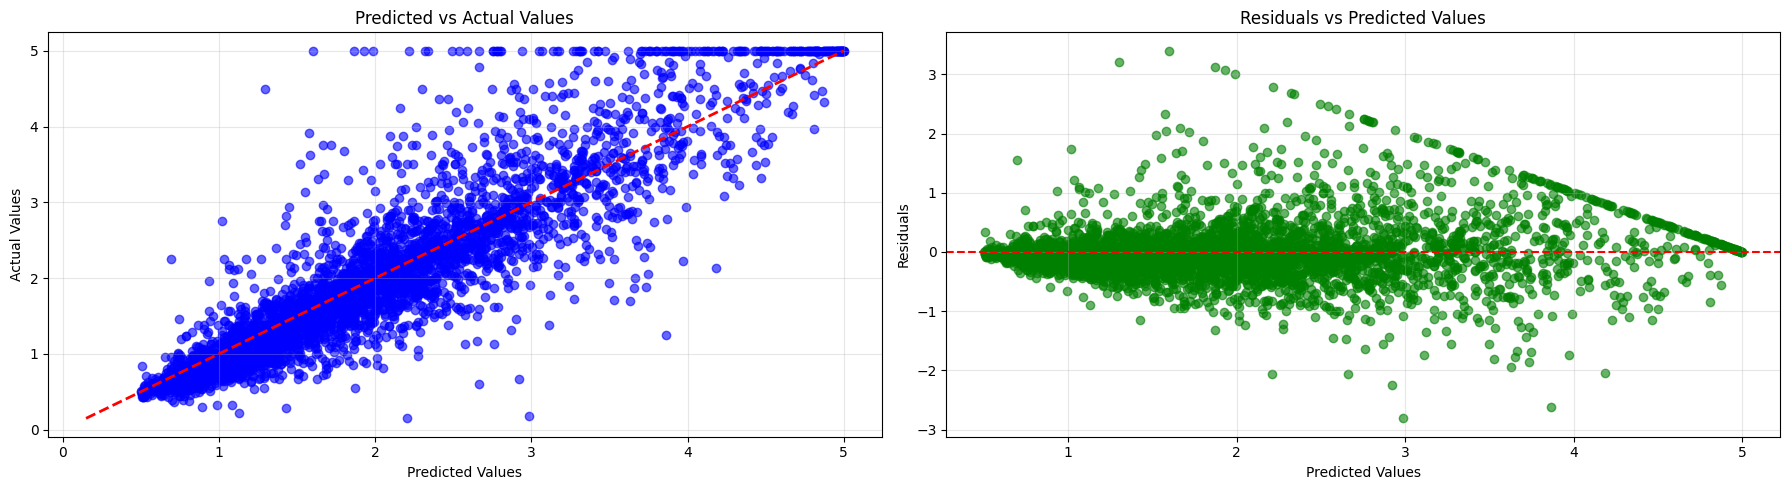

20046   -0.029992
3024    -0.357956
15663    0.183415
20484   -0.314798
9814     0.380166
           ...   
15362    0.292030
16623    0.872327
18086    0.227999
2144    -0.001514
3665    -0.198298
Name: MedHouseVal, Length: 4128, dtype: float64

In [8]:
dataset = fetch_california_housing(as_frame=True)

X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

best_params = optimize_hyperparameters(X_train, y_train, X_test, y_test, n_trials=50)

final_model = train_final_model(X_train, y_train, best_params)

y_pred, metrics = evaluate_model(final_model, X_test, y_test)

plot_residuals(y_test,y_pred)